In [1]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import torch
from torch.utils.data import TensorDataset
from torch import nn

from net_utils import load_from_file
import plotting
import networks
from networks import HebbFeatureLayer
import importlib
import os


/home/raaghav/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [16]:
for netFile, imgsFile, label in [
        ('publish/conv/HebbNet[50,16,1]_train=cur1_incr=plus1_w1init=randn_b1init=scalar_w2init=scalar.pkl',
                           'publish\conv\BradyOliva2008_UniqueObjects_ResNet18.pkl', 'featurize'),
]:

    folder, filename = os.path.split(netFile)
    idx = filename.find('[')
    if idx == -1:
        idx = filename.find('_')
    if idx == -1:
         raise ValueError('Invalid filename')  
    NetClass = getattr(importlib.import_module('networks'), filename[:idx])
    print(NetClass)   

    net = load_from_file(netFile)
    N,d = net.w1.shape
    print(net.hist['increment_R'][-1][1])
    x = torch.randn(10, d)
    check = net.featurizer(x).detach()



<class 'networks.HebbNet'>
17


AttributeError: 'HebbNet' object has no attribute 'featurizer'

### Plot generalization after training done

R=1, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.655)
R=2, truePos=1.000, falsePos=0.015, acc=0.990=0.990, (chance=0.655)
R=3, truePos=1.000, falsePos=0.022, acc=0.990=0.985, (chance=0.670)
R=4, truePos=1.000, falsePos=0.014, acc=0.995=0.990, (chance=0.705)
R=6, truePos=0.984, falsePos=0.029, acc=0.975=0.975, (chance=0.690)
R=8, truePos=0.984, falsePos=0.036, acc=0.970=0.970, (chance=0.690)
R=11, truePos=0.894, falsePos=0.006, acc=0.964=0.964, (chance=0.700)
R=15, truePos=0.588, falsePos=0.005, acc=0.870=0.863, (chance=0.677)
R=20, truePos=0.230, falsePos=0.032, acc=0.743=0.743, (chance=0.695)
R=26, truePos=0.075, falsePos=0.032, acc=0.673=0.671, (chance=0.667)
R=34, truePos=0.065, falsePos=0.024, acc=0.687=0.685, (chance=0.681)
R=45, truePos=0.054, falsePos=0.045, acc=0.663=0.661, (chance=0.673)
R=59, truePos=0.045, falsePos=0.058, acc=0.658=0.657, (chance=0.682)


array([<Axes: ylabel='Accuracy'>,
       <Axes: xlabel='$R_{test}$', ylabel='Probability'>], dtype=object)

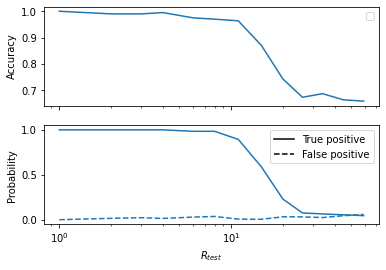

In [4]:
from networks import HebbFeatureLayer
from data import GenRecogClassifyData
from plotting import plot_generalization, get_recog_positive_rates

Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

Tmul = 20
Tmin = 200
P = 0.5 # Probability of repeat
noMultiRep = True

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze_augment_brady/results/HebbFeature_no_freeze_augment_brady_(10).pkl"
net.load(pretrained_weights)
img_dataset = "publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl"
images = torch.load(img_dataset)
dummyClasses = torch.zeros(images.shape[0],1)
sampleSpace = TensorDataset(images, dummyClasses)
generator = GenRecogClassifyData(sampleSpace=sampleSpace)
    
def generate_recog_data_batch(T,d,R,P,multiRep,batchSize,**kwargs):
    x,y = generator(T, R, P, batchSize, multiRep).tensors
    return TensorDataset(x, y[..., 0:1])

if type(net) == HebbFeatureLayer:
    assert images.shape[1] == Nx # sanity check

gen_data = lambda R: generate_recog_data_batch(T=max(Tmin, R*Tmul), 
                                                   d=d, 
                                                   R=R, 
                                                   P=P, 
                                                   softLabels=False,
                                                   interleave=True, 
                                                   multiRep=(not noMultiRep), 
                                                   batchSize=None,
                                                   xDataVals='+-',
                                                   device='cpu')

testR, testAcc, truePosRate, falsePosRate = get_recog_positive_rates(net, gen_data)
plot_generalization(testR, testAcc, truePosRate, falsePosRate)

plot_loss_acc skipped: 'valid_loss'


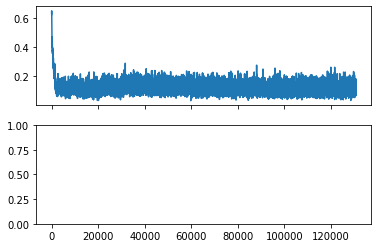

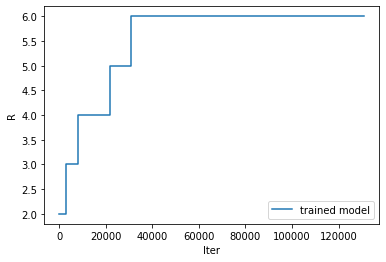

R=1, truePos=1.000, falsePos=0.008, acc=0.995=0.995, (chance=0.650)
R=2, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.690)
R=3, truePos=1.000, falsePos=0.000, acc=1.000=1.000, (chance=0.665)
R=4, truePos=1.000, falsePos=0.008, acc=0.995=0.995, (chance=0.640)
R=6, truePos=1.000, falsePos=0.029, acc=0.980=0.980, (chance=0.680)
R=8, truePos=0.984, falsePos=0.022, acc=0.985=0.980, (chance=0.690)
R=11, truePos=0.915, falsePos=0.020, acc=0.968=0.959, (chance=0.677)
R=15, truePos=0.578, falsePos=0.029, acc=0.853=0.853, (chance=0.700)
R=20, truePos=0.197, falsePos=0.033, acc=0.730=0.723, (chance=0.682)
R=26, truePos=0.090, falsePos=0.065, acc=0.665=0.665, (chance=0.681)
R=34, truePos=0.083, falsePos=0.044, acc=0.663=0.662, (chance=0.663)
R=45, truePos=0.072, falsePos=0.051, acc=0.664=0.663, (chance=0.674)
R=59, truePos=0.060, falsePos=0.045, acc=0.664=0.664, (chance=0.675)
R=77, truePos=0.037, falsePos=0.055, acc=0.658=0.658, (chance=0.684)


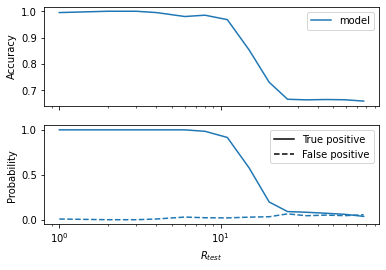

Plot distr R=1
Plot distr R=4
Plot distr R=21
Plot distr R=100


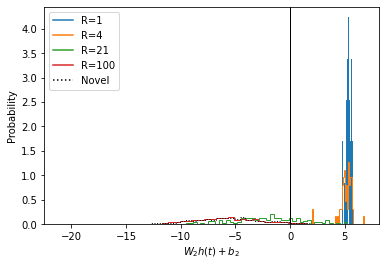

Plot RT R=1
Loading analysis_tmp_eval_R=1.pkl
Plot RT R=2
Plot RT R=4
Loading analysis_tmp_eval_R=4.pkl
Plot RT R=7
Plot RT R=12
Plot RT R=21
Loading analysis_tmp_eval_R=21.pkl
Plot RT R=35
Plot RT R=59
Plot RT R=100
Loading analysis_tmp_eval_R=100.pkl


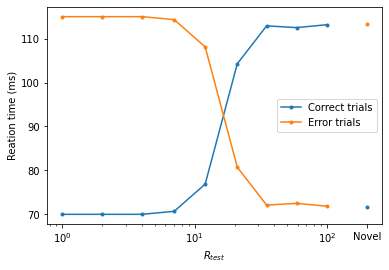

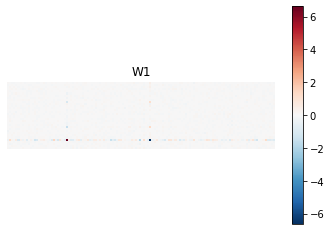

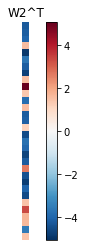

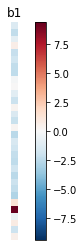

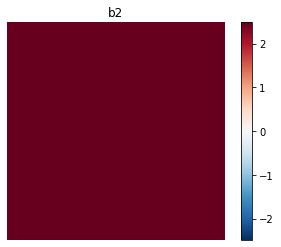

In [11]:
import plotting

# -------------------------
# 1) Load trained model
# -------------------------
ckpt = "results/tensor_board_logs_no_freeze_augment_brady/results/HebbFeature_no_freeze_augment_brady_(10).pkl"  # change

Nx = 512  # Raw image feature dimension (from ResNet output)
d = 128    # Compressed feature dimension
Nh = 32   # Hidden Hebbian layer size
Ny = 1    # Output dimension (recognition task)

net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
pretrained_weights = "results/tensor_board_logs_no_freeze_augment_brady/results/HebbFeature_no_freeze_augment_brady_(10).pkl"
net.load(pretrained_weights)

# -------------------------
# 2) Build gen_data(R)
# Choose ONE of the two options below
# -------------------------

# Option B: embeddings dataset (for HebbFeatureLayer with Nx-dim inputs)
def make_gen_data_embeddings(emb_path, Tmul=20, Tmin=200, P=0.5, multiRep=False):
    x = torch.load(emb_path)  # shape [N, Nx]
    y_dummy = torch.zeros(x.shape[0], 1)
    sample_space = TensorDataset(x, y_dummy)
    generator = GenRecogClassifyData(sampleSpace=sample_space)

    def gen_data(R):
        T = max(Tmin, int(R) * Tmul)
        xb, yb = generator(T=T, R=R, P=P, batchSize=None, multiRep=multiRep).tensors
        return TensorDataset(xb, yb[..., :1])  # recognition label only
    return gen_data

# pick one:
# gen_data = make_gen_data_synth(net)
gen_data = make_gen_data_embeddings("publish/conv/BradyOliva2008_UniqueObjects_ResNet18.pkl")

# -------------------------
# 3) Training curve (if available)
# -------------------------
try:
    plotting.plot_loss_acc(net)
    plt.show()
except Exception as e:
    print("plot_loss_acc skipped:", e)

# -------------------------
# 4) Curriculum trajectory R(iter)
# -------------------------
inc = net.hist.get("increment_R", [])
if len(inc) > 0:
    iters, Rs = map(list, zip(*inc))
    iters.append(net.hist.get("iter", iters[-1]))
    Rs.append(Rs[-1])
    plotting.plot_R_curriculum(iters, Rs, label="trained model")
    plt.legend()
    plt.show()
else:
    print("No increment_R found in net.hist")

# -------------------------
# 5) Generalization: acc, TP, FP vs R
# -------------------------
testR, testAcc, tp, fp = plotting.get_recog_positive_rates(
    net, gen_data, upToR=-float("inf"), stopAtR=300
)
ax = plotting.plot_generalization(testR, testAcc, tp, fp, label="model", xscale="log")
plt.show()

# -------------------------
# 6) Output/readout distributions over selected R
# -------------------------
Rs = np.unique(np.logspace(0, 2, 4, dtype=int))
plotting.plot_familiar_output_distr("analysis_tmp", gen_data, net=net, Rs=Rs, plotNov=True)
plt.show()

# -------------------------
# 7) Reaction-time-style curves
# -------------------------
plotting.plot_RT_curves("analysis_tmp", gen_data, Rs=np.unique(np.logspace(0, 2, 10, dtype=int)), net=net)
plt.show()

# -------------------------
# 8) Parameter heatmaps
# -------------------------
if hasattr(net, "w1"):
    plotting.plot_weight(net.w1.detach()); plt.title("W1"); plt.show()
if hasattr(net, "w2"):
    W2 = net.w2.detach().t() if net.w2.ndim == 2 else net.w2.detach().unsqueeze(1)
    plotting.plot_weight(W2); plt.title("W2^T"); plt.show()
if hasattr(net, "b1"):
    plotting.plot_weight(net.b1.detach().unsqueeze(1)); plt.title("b1"); plt.show()
if hasattr(net, "b2"):
    plotting.plot_weight(net.b2.detach().unsqueeze(1)); plt.title("b2"); plt.show()

### Check training logs

In [7]:
d = 50
Nh = 16
Ny = 1
Nx = 512

pkl_path = "results/tensor_board_logs_no_freeze/results/HebbFeature_no_freeze_(6).pkl"
net = HebbFeatureLayer(init=[d, Nh, Ny], Nx=Nx)
net.load(pkl_path)

# Inspect available history keys
print("hist keys:", list(net.hist.keys()))

# Expected format: net.hist["increment_R"] = [(iteration_idx, R_value), ...]
inc = net.hist.get("increment_R", None)
if inc is None or len(inc) == 0:
    raise ValueError("No 'increment_R' history found in this checkpoint.")

# Try to infer total number of training iterations
total_iters = None
for k in ["train_acc", "train_loss", "iters", "iter"]:
    if k in net.hist:
        try:
            total_iters = len(net.hist[k])
            break
        except TypeError:
            pass

if total_iters is None:
    # Fallback: use last recorded increment iteration as total boundary
    total_iters = int(inc[-1][0])

print(f"Total iterations (estimated): {total_iters}")
print("\nIterations trained per R:")

# Compute durations per R from increment points
# Each entry means: at iteration `it`, R becomes `Rval`
for i, (start_it, Rval) in enumerate(inc):
    end_it = inc[i + 1][0] if i + 1 < len(inc) else total_iters
    n_iters = int(end_it - start_it)
    print(f"R={Rval}: {n_iters} iterations (from {start_it} to {end_it})")

hist keys: ['epoch', 'iter', 'train_loss', 'train_acc', 'grad_norm', 'increment_R']
Total iterations (estimated): 4088

Iterations trained per R:
R=2: 4370 iterations (from 0 to 4370)
R=3: 2870 iterations (from 4370 to 7240)
R=4: 3660 iterations (from 7240 to 10900)
R=5: 7520 iterations (from 10900 to 18420)
R=6: 7170 iterations (from 18420 to 25590)
R=7: 15280 iterations (from 25590 to 40870)
R=8: -36782 iterations (from 40870 to 4088)
